# Retail Analysis

### Librerias y mi toolkit

In [1]:
import sys
sys.path.insert(0, "/home/aether/Data-Science/Python/python-utils")

import ast
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path



# --- Toolkit ---
from eda.summary       import describe_extended, variable_types
from eda.missing       import missing_report, missing_pattern, missing_correlation
from eda.outliers      import iqr_outliers, zscore_outliers, isolation_forest_outliers, outlier_report

from viz.distributions import plot_histogram, plot_boxplot, plot_distributions_grid
from viz.correlations  import plot_heatmap, plot_pairplot
from viz.model         import (plot_confusion_matrix, plot_roc_curve,
                               plot_precision_recall, plot_feature_importance)

from stats.normality        import normality_suite, shapiro_wilk
from stats.hypothesis_tests import compare_groups, chi_square, fisher_exact
from stats.correlation      import correlation_suite, correlation_matrix

from preprocessing.missing   import impute_simple, impute_knn, impute_auto
from preprocessing.encoders  import onehot_encode, ordinal_encode, target_encode
from preprocessing.pipeline  import make_preprocessor, make_pipeline

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")
SEED = 42
# Carpeta donde está este archivo
DATA_PATH = "/home/aether/Data-Science/Proyectos/Retail Analysis/Data/Sample - Superstore.csv"





/home/aether/.local/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.5' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/aether/.local/lib/python3.13/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
df=pd.read_csv(DATA_PATH, encoding="latin1")

In [3]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


### EDA 

In [4]:
variable_types(df)


  Tipos de Variable  (21 columnas)

  [CATEGÓRICA]  (5 columnas)
    • Ship Mode  (únicos=4)
    • Segment  (únicos=3)
    • Region  (únicos=4)
    • Category  (únicos=3)
    • Sub-Category  (únicos=17)

  [CONSTANTE]  (1 columnas)
    • Country  (únicos=1)

  [NUMÉRICA]  (6 columnas)
    • Row ID  (únicos=9994)
    • Postal Code  (únicos=631)
    • Sales  (únicos=5825)
    • Quantity  (únicos=14)
    • Discount  (únicos=12)
    • Profit  (únicos=7287)

  [TEXTO]  (9 columnas)
    • Order ID  (únicos=5009)
    • Order Date  (únicos=1237)
    • Ship Date  (únicos=1334)
    • Customer ID  (únicos=793)
    • Customer Name  (únicos=793)
    • City  (únicos=531)
    • State  (únicos=49)
    • Product ID  (únicos=1862)
    • Product Name  (únicos=1850)




,dtype,tipo,n_únicos,missing_%
columna,,,,
Row ID,int64,numérica,9994,0.0
Order ID,str,texto,5009,0.0
Order Date,str,texto,1237,0.0
Ship Date,str,texto,1334,0.0
Ship Mode,str,categórica,4,0.0
Customer ID,str,texto,793,0.0
Customer Name,str,texto,793,0.0
Segment,str,categórica,3,0.0
Country,str,constante,1,0.0


In [5]:
describe_extended(df)


  Resumen Estadístico Extendido  (filas=9994, cols=6)
               dtype  n_válidos  missing_%  n_únicos         media           std    CV_%       min           Q1     mediana         Q3        max          IQR  asimetría  curtosis      moda
columna                                                                                                                                                                                      
Row ID         int64       9994        0.0      9994   4997.500000   2885.163629   57.73     1.000   2499.25000   4997.5000   7495.750   9994.000   4996.50000     0.0000   -1.2000      1.00
Postal Code    int64       9994        0.0       631  55190.379428  32063.693350   58.10  1040.000  23223.00000  56430.5000  90008.000  99301.000  66785.00000    -0.1285   -1.4930  10035.00
Sales        float64       9994        0.0      5825    229.858001    623.245101  271.14     0.444     17.28000     54.4900    209.940  22638.480    192.66000    12.9728  305.3118     1

,dtype,n_válidos,missing_%,n_únicos,media,std,CV_%,min,Q1,mediana,Q3,max,IQR,asimetría,curtosis,moda
columna,,,,,,,,,,,,,,,,
Row ID,int64,9994,0.0,9994,4997.500000,2885.163629,57.73,1.000,2499.25000,4997.5000,7495.750,9994.000,4996.50000,0.0000,-1.2000,1.00
Postal Code,int64,9994,0.0,631,55190.379428,32063.693350,58.10,1040.000,23223.00000,56430.5000,90008.000,99301.000,66785.00000,-0.1285,-1.4930,10035.00
Sales,float64,9994,0.0,5825,229.858001,623.245101,271.14,0.444,17.28000,54.4900,209.940,22638.480,192.66000,12.9728,305.3118,12.96
Quantity,int64,9994,0.0,14,3.789574,2.225110,58.72,1.000,2.00000,3.0000,5.000,14.000,3.00000,1.2785,1.9919,3.00
Discount,float64,9994,0.0,12,0.156203,0.206452,132.17,0.000,0.00000,0.2000,0.200,0.800,0.20000,1.6843,2.4095,0.00
Profit,float64,9994,0.0,7287,28.656896,234.260108,817.47,-6599.978,1.72875,8.6665,29.364,8399.976,27.63525,7.5614,397.1885,0.00


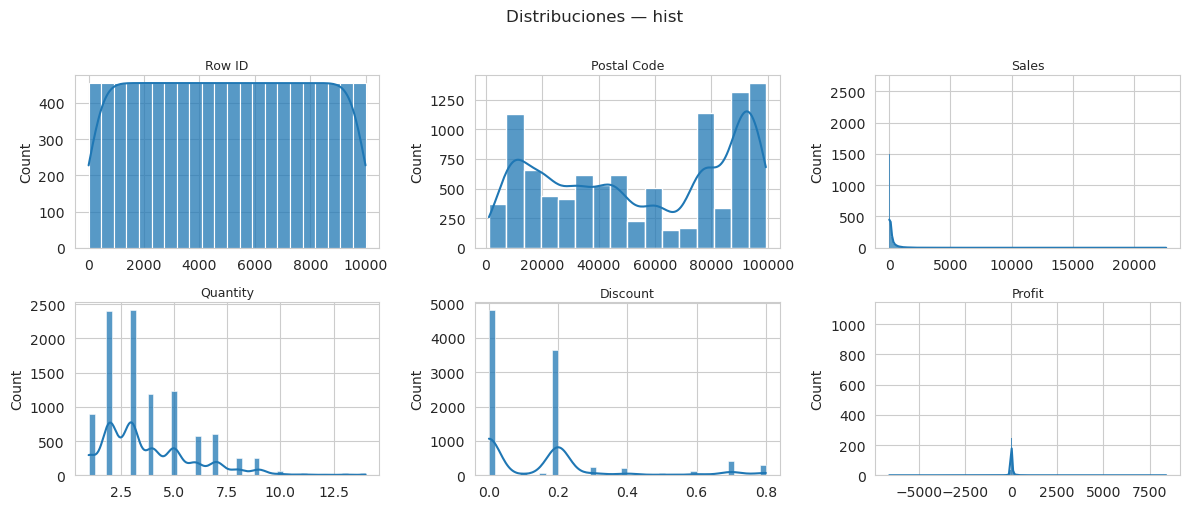

In [6]:
fig = plot_distributions_grid(
    df.select_dtypes('number'),
    ncols=3, kind='hist', kde=True,
    figsize_per_plot=(4,2.5),
    
)
plt.show()

### Missing report


In [7]:
missing_report(df)


  Valores Faltantes  (n=9994, cols_total=21)
  Sin valores faltantes.




,missing_n,missing_%,presente_n,dtype


### Data Wrangling

In [8]:
#Remover espacios

df['City'] = df['City'].str.strip()
df['State'] = df['State'].str.strip()
df['Country'] = df['Country'].str.strip()

In [9]:
#Títulos en mayúsculas

df['City'] = df['City'].str.title()
df['State'] = df['State'].str.title()
df['Country'] = df['Country'].str.title()

In [10]:
# Quitar espacios en blanco de los names de las columns

clean_df=df.copy()

str_cols = clean_df.select_dtypes(include='object').columns.tolist() #filtramos las columnas que son tipo objeto
for c in str_cols:
    print(c)
    clean_df[c] = clean_df[c].astype(str).str.strip()



Order ID
Order Date
Ship Date
Ship Mode
Customer ID
Customer Name
Segment
Country
City
State
Region
Product ID
Category
Sub-Category
Product Name


In [11]:
# Estandarizamos Category

clean_df['Category'] = clean_df['Category'].str.title()

clean_df['Sub-Category'] = clean_df['Sub-Category'].str.title()




In [12]:
# Columnas númericas

numcol=clean_df.select_dtypes(include='number').columns.tolist()

clean_df[numcol] = clean_df[numcol].apply(pd.to_numeric, errors='coerce')

In [13]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [14]:
# Detectamos los campos fecha

clean_df["Order Date"] = pd.to_datetime(clean_df["Order Date"], format='%m/%d/%Y' , errors='coerce')
clean_df["Ship Date"] = pd.to_datetime(clean_df["Ship Date"], format='%m/%d/%Y', errors='coerce')

In [15]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [16]:
#optimizando memoria para variables categoricas

cat=clean_df.select_dtypes(include='str').columns.tolist()
lis=[]
for c in cat:
    if len(clean_df[c].unique()) < 20:
        lis.append(c)

In [17]:
clean_df[lis]=clean_df[lis].astype('category')

In [18]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   category      
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   category      
 8   Country        9994 non-null   category      
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   category      
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   category      
 15  Sub-Category   9994 non-null   c

### Feature Engineering

In [19]:
#Fechas - Días, meses y años. 

clean_df["Order_Day"] = clean_df["Order Date"].dt.day
clean_df["Order_Month"] = clean_df["Order Date"].dt.month
clean_df["Order_Year"] = clean_df["Order Date"].dt.year
clean_df['Order_Quarter'] = clean_df['Order Date'].dt.to_period('Q')

clean_df["Ship_Day"] = clean_df["Ship Date"].dt.day
clean_df["Ship_Month"] = clean_df["Ship Date"].dt.month
clean_df["Ship_Year"] = clean_df["Ship Date"].dt.year
clean_df['Ship_Quarter'] = clean_df['Ship Date'].dt.to_period('Q')

In [20]:
#Nombre de la semana y determinar si es finde

clean_df['Order_Weekday'] = clean_df['Order Date'].dt.day_name()
clean_df['Is_Weekend'] = clean_df['Order_Weekday'].isin(['Friday', 'Saturday', 'Sunday']).astype(int)

In [21]:
# Duración

clean_df['Ship_Duration']=(clean_df['Ship Date']-clean_df['Order Date']).dt.days

In [22]:
# Margen

clean_df['Profit_Margin'] = clean_df['Profit'] / clean_df['Sales']

In [23]:
# Revenue

clean_df['Revenue_Before_Discount'] = clean_df['Sales'] / (1 - clean_df['Discount'])

In [24]:
# Descuentos altos

threshold = 0.25
clean_df['High_Discount_Flag'] = (clean_df['Discount'] > threshold).astype(int)


In [25]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Row ID                   9994 non-null   int64         
 1   Order ID                 9994 non-null   str           
 2   Order Date               9994 non-null   datetime64[us]
 3   Ship Date                9994 non-null   datetime64[us]
 4   Ship Mode                9994 non-null   category      
 5   Customer ID              9994 non-null   str           
 6   Customer Name            9994 non-null   str           
 7   Segment                  9994 non-null   category      
 8   Country                  9994 non-null   category      
 9   City                     9994 non-null   str           
 10  State                    9994 non-null   str           
 11  Postal Code              9994 non-null   int64         
 12  Region                   9994 non-null   cate

In [26]:
clean_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Ship_Day,Ship_Month,Ship_Year,Ship_Quarter,Order_Weekday,Is_Weekend,Ship_Duration,Profit_Margin,Revenue_Before_Discount,High_Discount_Flag
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,11,11,2016,2016Q4,Tuesday,0,3,0.1600,261.96,0
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,11,11,2016,2016Q4,Tuesday,0,3,0.3000,731.94,0
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,16,6,2016,2016Q2,Sunday,1,4,0.4700,14.62,0
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,18,10,2015,2015Q4,Sunday,1,7,-0.4000,1741.05,1
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,18,10,2015,2015Q4,Sunday,1,7,0.1125,27.96,0


### Modelo Estrella

In [27]:
from graphviz import Digraph

erd = Digraph("Superstore_ERD", format="png")
erd.attr(rankdir="LR", bgcolor="white")

fact_color = "lightcoral"
dim_color = "lightblue"

# Fact
erd.node("FactSales", """FactSales
-------------------
Row ID (PK)
Order ID (BK)
Customer Key (FK)
Product Key (FK)
Order Date ID (FK)
Ship Date ID (FK)
Ship Mode ID (FK)
Location ID (FK)
Sales
Quantity
Discount
Revenue_Before_Discount
Profit
Profit_Margin
Ship_Duration
High_Discount_Flag""", shape="box", style="filled", fillcolor=fact_color)

# Dim
erd.node("DimDate", """DimDate
-------------------
Date ID (PK)
Full Date
Day
Month
Year
Quarter
Weekday
Is_Weekend""", shape="box", style="filled", fillcolor=dim_color)

erd.node("DimCustomer", """DimCustomer
-------------------
Customer Key (PK)
Customer ID (NK)
Customer Name
Segment""", shape="box", style="filled", fillcolor=dim_color)

erd.node("DimLocation", """DimLocation
-------------------
Location ID (PK)
Country
State
City
Region
Postal Code""", shape="box", style="filled", fillcolor=dim_color)

erd.node("DimProduct", """DimProduct
-------------------
Product Key (PK)
Product ID (NK)
Product Name
Category
Sub-Category""", shape="box", style="filled", fillcolor=dim_color)

erd.node("DimShipMode", """DimShipMode
-------------------
Ship Mode ID (PK)
Ship Mode""", shape="box", style="filled", fillcolor=dim_color)


erd.edge("FactSales", "DimDate", label="Order Date ID → Date ID")
erd.edge("FactSales", "DimDate", label="Ship Date ID → Date ID")
erd.edge("FactSales", "DimCustomer", label="Customer Key → Customer Key")
erd.edge("FactSales", "DimLocation", label="Location ID → Location ID")
erd.edge("FactSales", "DimProduct", label="Product Key → Product Key")
erd.edge("FactSales", "DimShipMode", label="Ship Mode ID → Ship Mode ID")


file_path = "/home/aether/Data-Science/Proyectos/Retail Analysis/Img/imagen"
erd.render(file_path, cleanup=True)

file_path + ".png"

'/home/aether/Data-Science/Proyectos/Retail Analysis/Img/imagen.png'

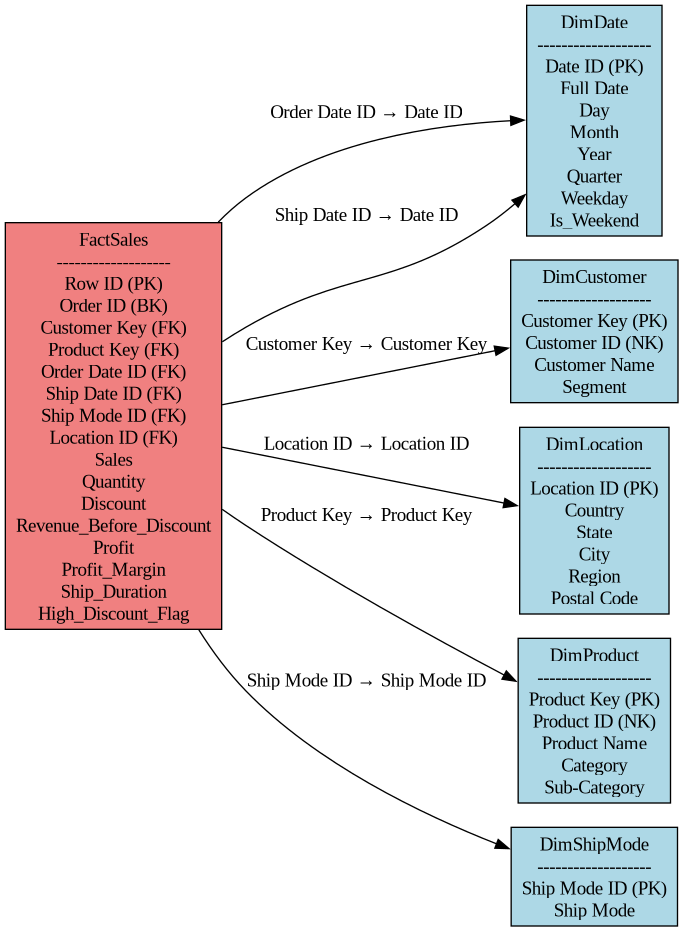

In [28]:


from IPython.display import Image
Image(file_path + ".png")



### Tablas

In [29]:
#dimdate

dates = pd.concat([clean_df['Order Date'], clean_df['Ship Date']]).drop_duplicates().reset_index(drop=True)
dim_date = pd.DataFrame({'Full Date': dates})
dim_date['Date ID'] = dim_date.index + 1
dim_date['Day'] = dim_date['Full Date'].dt.day
dim_date['Month'] = dim_date['Full Date'].dt.month
dim_date['Year'] = dim_date['Full Date'].dt.year
dim_date['Quarter'] = dim_date['Full Date'].dt.quarter
dim_date['Weekday'] = dim_date['Full Date'].dt.day_name()
dim_date['Is_Weekend'] = dim_date['Weekday'].isin(['Saturday', 'Sunday']).astype(int)

In [30]:
#dim_customer

dim_customer = clean_df[['Customer ID', 'Customer Name', 'Segment']].drop_duplicates(subset=['Customer ID']).reset_index(drop=True)
dim_customer.insert(0, 'Customer Key', dim_customer.index + 1)

In [31]:
#dim_location

dim_location = clean_df[['Country', 'State', 'City', 'Region', 'Postal Code']].drop_duplicates().reset_index(drop=True)
dim_location['Location ID'] = dim_location.index + 1
dim_location = dim_location[['Location ID', 'Country', 'State', 'City', 'Region', 'Postal Code']]

In [32]:
#dim_product

dim_product = clean_df[['Product ID', 'Product Name', 'Category', 'Sub-Category']].drop_duplicates(subset=['Product ID']).reset_index(drop=True)
dim_product.insert(0, 'Product Key', dim_product.index + 1)

In [33]:
#dim_shipmode

dim_shipmode = df[['Ship Mode']].drop_duplicates().reset_index(drop=True)
dim_shipmode['Ship Mode ID'] = dim_shipmode.index + 1
dim_shipmode = dim_shipmode[['Ship Mode ID', 'Ship Mode']]


In [34]:
#Fact

fact_sales = clean_df.copy()
fact_sales = fact_sales.merge(dim_date[['Date ID', 'Full Date']],
                              left_on='Order Date', right_on='Full Date', how='left') \
                       .rename(columns={'Date ID': 'Order Date ID'}).drop(columns=['Full Date'])

fact_sales = fact_sales.merge(dim_date[['Date ID', 'Full Date']],
                              left_on='Ship Date', right_on='Full Date', how='left') \
                       .rename(columns={'Date ID': 'Ship Date ID'}).drop(columns=['Full Date'])

fact_sales = fact_sales.merge(dim_location[['Location ID', 'Country', 'State', 'City', 'Region', 'Postal Code']],
                              on=['Country','State','City','Region','Postal Code'], how='left')

fact_sales = fact_sales.merge(dim_shipmode, on='Ship Mode', how='left')

fact_sales = fact_sales.merge(dim_customer[['Customer Key', 'Customer ID']],
                              on='Customer ID', how='left')

fact_sales = fact_sales.merge(dim_product[['Product Key', 'Product ID']],
                              on='Product ID', how='left')

fact_sales = fact_sales[['Row ID', 'Order ID', 'Customer Key', 'Product Key',
                         'Order Date ID', 'Ship Date ID', 'Ship Mode ID', 'Location ID',
                         'Sales', 'Quantity', 'Discount', 'Revenue_Before_Discount',
                         'Profit', 'Profit_Margin', 'Ship_Duration', 'High_Discount_Flag']]

In [35]:
#Guardamos

dim_date.to_csv("Data/DimDate.csv", index=False)
dim_customer.to_csv("Data/DimCustomer.csv", index=False)
dim_product.to_csv("Data/DimProduct.csv", index=False)
dim_location.to_csv("Data/DimLocation.csv", index=False)
dim_shipmode.to_csv("Data/DimShipMode.csv", index=False)

fact_sales.to_csv("Data/FactSales.csv", index=False)




### AWS

In [36]:
import pandas as pd
from sqlalchemy import create_engine, text

# Reemplaza con tus valores del Tema 01
AURORA_HOST     = "aurora4-mod.cluster-cfx7stygivll.us-east-1.rds.amazonaws.com"
AURORA_PASSWORD = "zgmqov88"
AURORA_DATABASE = "northwind"

engine = create_engine(
    f"postgresql+psycopg2://postgres:{AURORA_PASSWORD}@{AURORA_HOST}:5432/{AURORA_DATABASE}"
)

In [37]:
with engine.connect() as conn:
    version = conn.execute(text("SELECT version()")).scalar()
    print(version)

PostgreSQL 17.7 on x86_64-pc-linux-gnu, compiled by x86_64-pc-linux-gnu-gcc (GCC) 10.5.0, 64-bit


In [38]:
with engine.begin() as conn:
    conn.execute(text("CREATE SCHEMA IF NOT EXISTS retail_py"))

print("✓ schema retail_py listo")

✓ schema retail_py listo


In [39]:
dim_date=pd.read_csv("Data/DimDate.csv")
dim_customer=pd.read_csv("Data/DimCustomer.csv")
dim_product=pd.read_csv("Data/DimProduct.csv")
dim_location=pd.read_csv("Data/DimLocation.csv")
dim_shipmode=pd.read_csv("Data/DimShipMode.csv")
fact_sales=pd.read_csv("Data/FactSales.csv")


In [40]:
engine.dispose()

In [41]:
# Carga ordenada de las 5 dims + fact_sales
tablas_en_orden = [
    ("dim_date",     dim_date),
    ("dim_customer", dim_customer),
    ("dim_product",  dim_product),
    ("dim_shipmode",  dim_shipmode),
    ("dim_location",  dim_location),
    ("fact_sales",   fact_sales),
]

for nombre, df in tablas_en_orden:
    df.to_sql(
        name=nombre,
        con=engine,
        schema="retail_py",
        if_exists="replace",
        index=False,
        chunksize=1000,
        method="multi",
    )
    print(f"✓ {nombre:14s} {len(df):>5} filas")

print("\nCarga completa.")

✓ dim_date        1434 filas
✓ dim_customer     793 filas
✓ dim_product     1862 filas
✓ dim_shipmode       4 filas
✓ dim_location     632 filas
✓ fact_sales      9994 filas

Carga completa.


In [42]:
# PK + FK para que DBeaver dibuje el modelo estrella
constraints_sql = """
ALTER TABLE retail_py.dim_date      ADD PRIMARY KEY ("Date ID");
ALTER TABLE retail_py.dim_customer  ADD PRIMARY KEY ("Customer Key");
ALTER TABLE retail_py.dim_product   ADD PRIMARY KEY ("Product Key");
ALTER TABLE retail_py.dim_location  ADD PRIMARY KEY ("Location ID");
ALTER TABLE retail_py.dim_shipmode  ADD PRIMARY KEY ("Ship Mode ID");
ALTER TABLE retail_py.fact_sales    ADD PRIMARY KEY ("Row ID");

ALTER TABLE retail_py.fact_sales
    ADD CONSTRAINT fk_order_date FOREIGN KEY ("Order Date ID") REFERENCES retail_py.dim_date("Date ID"),
    ADD CONSTRAINT fk_ship_date  FOREIGN KEY ("Ship Date ID")  REFERENCES retail_py.dim_date("Date ID"),
    ADD CONSTRAINT fk_customer   FOREIGN KEY ("Customer Key")  REFERENCES retail_py.dim_customer("Customer Key"),
    ADD CONSTRAINT fk_product    FOREIGN KEY ("Product Key")   REFERENCES retail_py.dim_product("Product Key"),
    ADD CONSTRAINT fk_location   FOREIGN KEY ("Location ID")   REFERENCES retail_py.dim_location("Location ID"),
    ADD CONSTRAINT fk_shipmode   FOREIGN KEY ("Ship Mode ID")  REFERENCES retail_py.dim_shipmode("Ship Mode ID")
"""

with engine.begin() as conn:
    for stmt in constraints_sql.strip().split(";"):
        if stmt.strip():
            conn.execute(text(stmt))
print("✓ constraints aplicadas")

✓ constraints aplicadas



### SQL


In [1]:
# Setup JupySQL
import importlib.util, subprocess, sys
if importlib.util.find_spec("jupysql") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "jupysql"], check=True)

%load_ext sql
%config SqlMagic.autopandas     = True
%config SqlMagic.feedback       = False
%config SqlMagic.displaycon     = False

from sqlalchemy import create_engine, text
AURORA_HOST     = "aurora4-mod.cluster-cfx7stygivll.us-east-1.rds.amazonaws.com"
AURORA_PASSWORD = "zgmqov88"
AURORA_DATABASE = "northwind"
engine_sql = create_engine(
    f"postgresql+psycopg2://postgres:{AURORA_PASSWORD}@{AURORA_HOST}:5432/{AURORA_DATABASE}"
)
%sql engine_sql

/home/aether/.local/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.5' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/aether/.local/lib/python3.13/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


#### 1 · KPIs globales

In [2]:
%%sql
SELECT
    COUNT(DISTINCT "Order ID")                        AS total_ordenes,
    COUNT(*)                                          AS lineas_venta,
    ROUND(CAST(SUM("Sales")   AS NUMERIC), 2)         AS ventas_totales,
    ROUND(CAST(SUM("Profit")  AS NUMERIC), 2)         AS profit_total,
    ROUND(CAST(AVG("Profit_Margin") * 100 AS NUMERIC), 2) AS margen_pct,
    ROUND(CAST(AVG("Discount") * 100 AS NUMERIC), 2)  AS descuento_medio_pct
FROM retail_py.fact_sales;

,total_ordenes,lineas_venta,ventas_totales,profit_total,margen_pct,descuento_medio_pct
0,5009,9994,2297200.86,286397.02,12.03,15.62


#### 2 · Ventas y margen por categoría

In [3]:
%%sql
SELECT
    dp."Category"                                           AS categoria,
    COUNT(*)                                                AS lineas,
    ROUND(CAST(SUM(fs."Sales")  AS NUMERIC), 2)            AS ventas,
    ROUND(CAST(SUM(fs."Profit") AS NUMERIC), 2)            AS profit,
    ROUND(CAST(AVG(fs."Profit_Margin") * 100 AS NUMERIC), 2) AS margen_pct,
    ROUND(CAST(SUM(fs."Sales") * 100.0
          / SUM(SUM(fs."Sales")) OVER () AS NUMERIC), 2)  AS pct_ventas_global
FROM retail_py.fact_sales   fs
JOIN retail_py.dim_product  dp ON fs."Product Key" = dp."Product Key"
GROUP BY dp."Category"
ORDER BY ventas DESC;

,categoria,lineas,ventas,profit,margen_pct,pct_ventas_global
0,Technology,1847,836154.03,145454.95,15.61,36.40
1,Furniture,2121,741999.80,18451.27,3.88,32.30
2,Office Supplies,6026,719047.03,122490.80,13.80,31.30


#### 3 · Tendencia mensual de ventas (DATE_TRUNC)

In [4]:
%%sql
SELECT
    DATE_TRUNC('month', dd."Full Date"::date)           AS mes,
    ROUND(CAST(SUM(fs."Sales")  AS NUMERIC), 2)         AS ventas,
    ROUND(CAST(SUM(fs."Profit") AS NUMERIC), 2)         AS profit,
    COUNT(DISTINCT fs."Order ID")                       AS ordenes
FROM retail_py.fact_sales  fs
JOIN retail_py.dim_date    dd ON fs."Order Date ID" = dd."Date ID"
GROUP BY mes
ORDER BY mes;

,mes,ventas,profit,ordenes
0,2014-01-01 00:00:00+00:00,14236.90,2450.19,32
1,2014-02-01 00:00:00+00:00,4519.89,862.31,28
2,2014-03-01 00:00:00+00:00,55691.01,498.73,71
3,2014-04-01 00:00:00+00:00,28295.35,3488.84,66
4,2014-05-01 00:00:00+00:00,23648.29,2738.71,69
5,2014-06-01 00:00:00+00:00,34595.13,4976.52,66
6,2014-07-01 00:00:00+00:00,33946.39,-841.48,65
7,2014-08-01 00:00:00+00:00,27909.47,5318.11,72
8,2014-09-01 00:00:00+00:00,81777.35,8328.10,130
9,2014-10-01 00:00:00+00:00,31453.39,3448.26,78


#### 4 · Window function — Ranking de productos por ventas dentro de su categoría

#### 5 · Window function — Crecimiento MoM con LAG

In [5]:
%%sql
WITH ventas_mes AS (
    SELECT
        DATE_TRUNC('month', dd."Full Date"::date)       AS mes,
        ROUND(CAST(SUM(fs."Sales") AS NUMERIC), 2)      AS ventas
    FROM retail_py.fact_sales fs
    JOIN retail_py.dim_date   dd ON fs."Order Date ID" = dd."Date ID"
    GROUP BY mes
)
SELECT
    mes,
    ventas,
    LAG(ventas) OVER (ORDER BY mes)                      AS ventas_mes_anterior,
    ROUND(
        (ventas - LAG(ventas) OVER (ORDER BY mes))
        * 100.0 / NULLIF(LAG(ventas) OVER (ORDER BY mes), 0)
    , 2)                                                 AS crecimiento_pct
FROM ventas_mes
ORDER BY mes;

,mes,ventas,ventas_mes_anterior,crecimiento_pct
0,2014-01-01 00:00:00+00:00,14236.90,None,None
1,2014-02-01 00:00:00+00:00,4519.89,14236.90,-68.25
2,2014-03-01 00:00:00+00:00,55691.01,4519.89,1132.13
3,2014-04-01 00:00:00+00:00,28295.35,55691.01,-49.19
4,2014-05-01 00:00:00+00:00,23648.29,28295.35,-16.42
5,2014-06-01 00:00:00+00:00,34595.13,23648.29,46.29
6,2014-07-01 00:00:00+00:00,33946.39,34595.13,-1.88
7,2014-08-01 00:00:00+00:00,27909.47,33946.39,-17.78
8,2014-09-01 00:00:00+00:00,81777.35,27909.47,193.01
9,2014-10-01 00:00:00+00:00,31453.39,81777.35,-61.54


#### 6 · Window function — Running total de ventas acumuladas

In [6]:
%%sql
WITH ventas_mes AS (
    SELECT
        DATE_TRUNC('month', dd."Full Date"::date)   AS mes,
        ROUND(CAST(SUM(fs."Sales") AS NUMERIC), 2)  AS ventas
    FROM retail_py.fact_sales fs
    JOIN retail_py.dim_date   dd ON fs."Order Date ID" = dd."Date ID"
    GROUP BY mes
)
SELECT
    mes,
    ventas,
    SUM(ventas) OVER (
        PARTITION BY EXTRACT(YEAR FROM mes)
        ORDER BY mes
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ) AS ventas_acumuladas_ytd
FROM ventas_mes
ORDER BY mes;

,mes,ventas,ventas_acumuladas_ytd
0,2014-01-01 00:00:00+00:00,14236.90,14236.90
1,2014-02-01 00:00:00+00:00,4519.89,18756.79
2,2014-03-01 00:00:00+00:00,55691.01,74447.80
3,2014-04-01 00:00:00+00:00,28295.35,102743.15
4,2014-05-01 00:00:00+00:00,23648.29,126391.44
5,2014-06-01 00:00:00+00:00,34595.13,160986.57
6,2014-07-01 00:00:00+00:00,33946.39,194932.96
7,2014-08-01 00:00:00+00:00,27909.47,222842.43
8,2014-09-01 00:00:00+00:00,81777.35,304619.78
9,2014-10-01 00:00:00+00:00,31453.39,336073.17


#### 7 · CTE — Top 10 clientes por revenue con % de participación

In [7]:
%%sql
WITH resumen_cliente AS (
    SELECT
        dc."Customer Name"                               AS cliente,
        dc."Segment"                                     AS segmento,
        ROUND(CAST(SUM(fs."Sales")  AS NUMERIC), 2)     AS ventas,
        ROUND(CAST(SUM(fs."Profit") AS NUMERIC), 2)     AS profit,
        COUNT(DISTINCT fs."Order ID")                   AS ordenes
    FROM retail_py.fact_sales    fs
    JOIN retail_py.dim_customer  dc ON fs."Customer Key" = dc."Customer Key"
    GROUP BY dc."Customer Name", dc."Segment"
)
SELECT
    cliente,
    segmento,
    ventas,
    profit,
    ordenes,
    ROUND(ventas * 100.0 / SUM(ventas) OVER (), 2)  AS pct_ventas_global,
    RANK() OVER (ORDER BY ventas DESC)              AS ranking
FROM resumen_cliente
ORDER BY ventas DESC
LIMIT 10;

,cliente,segmento,ventas,profit,ordenes,pct_ventas_global,ranking
0,Sean Miller,Home Office,25043.05,-1980.74,5,1.09,1
1,Tamara Chand,Corporate,19052.22,8981.32,5,0.83,2
2,Raymond Buch,Consumer,15117.34,6976.10,6,0.66,3
3,Tom Ashbrook,Home Office,14595.62,4703.79,4,0.64,4
4,Adrian Barton,Consumer,14473.57,5444.81,10,0.63,5
5,Ken Lonsdale,Consumer,14175.23,806.86,12,0.62,6
6,Sanjit Chand,Consumer,14142.33,5757.41,9,0.62,7
7,Hunter Lopez,Consumer,12873.30,5622.43,6,0.56,8
8,Sanjit Engle,Consumer,12209.44,2650.68,11,0.53,9
9,Christopher Conant,Consumer,12129.07,2177.05,5,0.53,10


#### 8 · Subquery correlacionado — Productos con ventas sobre el promedio de su categoría

In [8]:
%%sql
SELECT
    dp_outer."Category"                                   AS categoria,
    dp_outer."Product Name"                               AS producto,
    ROUND(CAST(SUM(fs_outer."Sales") AS NUMERIC), 2)     AS ventas_producto,
    ROUND(CAST((
        SELECT AVG(fs_inner."Sales")
        FROM retail_py.fact_sales  fs_inner
        JOIN retail_py.dim_product dp_inner ON fs_inner."Product Key" = dp_inner."Product Key"
        WHERE dp_inner."Category" = dp_outer."Category"
    ) AS NUMERIC), 2)                                     AS promedio_categoria
FROM retail_py.fact_sales  fs_outer
JOIN retail_py.dim_product dp_outer ON fs_outer."Product Key" = dp_outer."Product Key"
GROUP BY dp_outer."Category", dp_outer."Product Name"
HAVING SUM(fs_outer."Sales") > (
    SELECT AVG(sub.total)
    FROM (
        SELECT SUM(fs2."Sales") AS total
        FROM retail_py.fact_sales  fs2
        JOIN retail_py.dim_product dp2 ON fs2."Product Key" = dp2."Product Key"
        WHERE dp2."Category" = dp_outer."Category"
        GROUP BY dp2."Product Name"
    ) sub
)
ORDER BY categoria, ventas_producto DESC;

,categoria,producto,ventas_producto,promedio_categoria
0,Furniture,HON 5400 Series Task Chairs for Big and Tall,21870.58,349.83
1,Furniture,"Riverside Palais Royal Lawyers Bookcase, Royal...",15610.97,349.83
2,Furniture,Bretford Rectangular Conference Table Tops,12995.29,349.83
3,Furniture,Global Troy Executive Leather Low-Back Tilter,12975.38,349.83
4,Furniture,DMI Eclipse Executive Suite Bookcases,12921.64,349.83
...,...,...,...,...
407,Technology,Razer Kraken PRO Over Ear PC and Music Headset,2159.73,452.71
408,Technology,Logitech G35 7.1-Channel Surround Sound Headset,2157.83,452.71
409,Technology,Samsung Galaxy Note 3,2155.90,452.71
410,Technology,Mitel 5320 IP Phone VoIP phone,2116.69,452.71


#### 9 · Análisis de descuentos — Impacto en margen con CASE WHEN

In [9]:
%%sql
SELECT
    CASE
        WHEN "Discount" = 0          THEN '0%'
        WHEN "Discount" <= 0.10      THEN '1-10%'
        WHEN "Discount" <= 0.20      THEN '11-20%'
        WHEN "Discount" <= 0.30      THEN '21-30%'
        ELSE '> 30%'
    END                                                   AS tramo_descuento,
    COUNT(*)                                              AS lineas,
    ROUND(CAST(AVG("Sales")          AS NUMERIC), 2)    AS venta_media,
    ROUND(CAST(AVG("Profit")         AS NUMERIC), 2)    AS profit_medio,
    ROUND(CAST(AVG("Profit_Margin") * 100 AS NUMERIC), 2) AS margen_medio_pct
FROM retail_py.fact_sales
GROUP BY tramo_descuento
ORDER BY MIN("Discount");

,tramo_descuento,lineas,venta_media,profit_medio,margen_medio_pct
0,0%,4798,226.74,66.90,34.02
1,1-10%,94,578.40,96.06,15.58
2,11-20%,3709,213.58,24.74,17.48
3,21-30%,227,454.74,-45.68,-11.55
4,> 30%,1166,222.59,-107.21,-91.47



### Visualizaciones



In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings("ignore")

# ── Cargar datos ──────────────────────────────────────────────────────────────
fact     = pd.read_csv("Data/FactSales.csv")
d_date   = pd.read_csv("Data/DimDate.csv")
d_cat    = pd.read_csv("Data/DimProduct.csv")
d_cust   = pd.read_csv("Data/DimCustomer.csv")
d_loc    = pd.read_csv("Data/DimLocation.csv")

d_date["Full Date"] = pd.to_datetime(d_date["Full Date"])

# Joins base
fs = (fact
      .merge(d_date.rename(columns={"Date ID": "Order Date ID"}),
             on="Order Date ID", how="left")
      .merge(d_cat,  on="Product Key",  how="left")
      .merge(d_cust, on="Customer Key", how="left")
      .merge(d_loc,  on="Location ID",  how="left"))

fs["Year"]  = fs["Full Date"].dt.year
fs["Month"] = fs["Full Date"].dt.month
fs["YM"]    = fs["Full Date"].dt.to_period("M")

# ── Paleta y estilo global ─────────────────────────────────────────────────────
C = {
    "bg":      "#FAFAF8",
    "panel":   "#F2F1EE",
    "grid":    "#E8E7E3",
    "ink":     "#1C1C1E",
    "muted":   "#8E8E93",
    "tech":    "#5E5CE6",   # Technology
    "furn":    "#FF9F0A",   # Furniture
    "off":     "#30D158",   # Office Supplies
    "accent":  "#FF375F",
    "teal":    "#64D2FF",
}

CATS   = ["Technology", "Furniture", "Office Supplies"]
CCOLOR = [C["tech"], C["furn"], C["off"]]

plt.rcParams.update({
    "figure.facecolor":  C["bg"],
    "axes.facecolor":    C["bg"],
    "axes.edgecolor":    C["grid"],
    "axes.linewidth":    0.8,
    "axes.grid":         True,
    "grid.color":        C["grid"],
    "grid.linewidth":    0.6,
    "grid.linestyle":    "-",
    "xtick.color":       C["muted"],
    "ytick.color":       C["muted"],
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
    "font.family":       "DejaVu Sans",
    "text.color":        C["ink"],
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.spines.left":  True,
    "axes.spines.bottom":True,
})

def subtitle(ax, txt):
    ax.set_title(txt, fontsize=8, color=C["muted"], pad=4, loc="left")

def title(ax, txt):
    ax.text(0, 1.06, txt, transform=ax.transAxes,
            fontsize=11, fontweight="bold", color=C["ink"], va="bottom")

print("✓ setup listo")


✓ setup listo


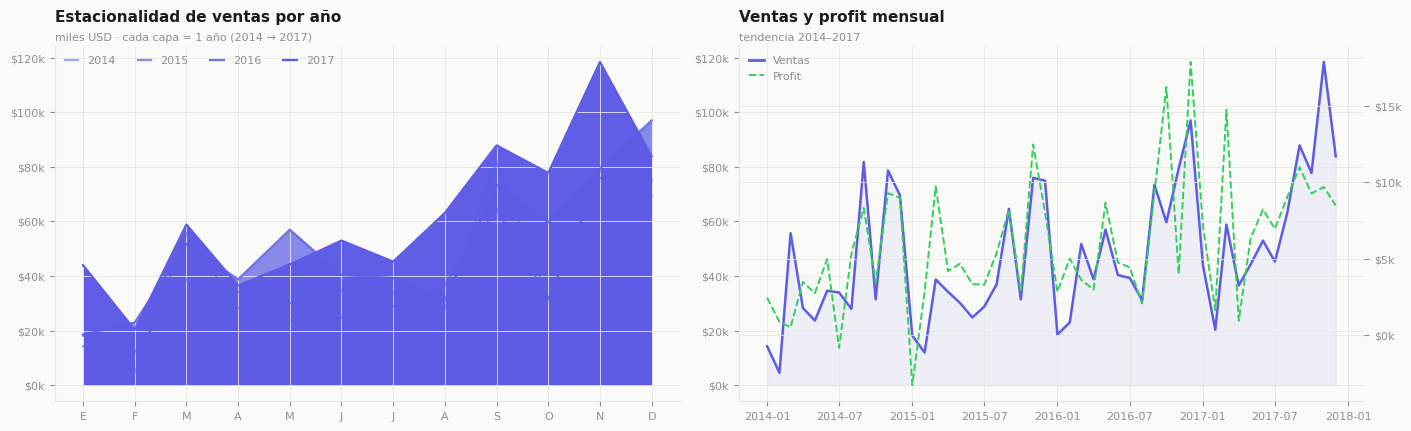

In [11]:
monthly = (fs.groupby(["Year", "Month"])
             .agg(Sales=("Sales","sum"), Profit=("Profit","sum"))
             .reset_index())
monthly["date"] = pd.to_datetime(dict(year=monthly.Year,
                                      month=monthly.Month, day=1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2),
                          facecolor=C["bg"], constrained_layout=True)
fig.patch.set_facecolor(C["bg"])

# — izquierda: área acumulada por año —
for yr, grp in monthly.groupby("Year"):
    alpha = 0.18 + 0.27 * (yr - 2014)
    axes[0].fill_between(grp["Month"], grp["Sales"]/1e3,
                         alpha=alpha, color=C["tech"], linewidth=0)
    axes[0].plot(grp["Month"], grp["Sales"]/1e3,
                 color=C["tech"], linewidth=1.6, alpha=0.55 + 0.15*(yr-2014),
                 label=str(yr))

axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(["E","F","M","A","M","J","J","A","S","O","N","D"])
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"${x:.0f}k"))
axes[0].legend(frameon=False, fontsize=8, ncol=4,
               labelcolor=C["muted"], handlelength=1.2)
title(axes[0], "Estacionalidad de ventas por año")
subtitle(axes[0], "miles USD · cada capa = 1 año (2014 → 2017)")

# — derecha: ventas vs profit mensual (dual line) —
all_m = (fs.groupby("YM")
           .agg(Sales=("Sales","sum"), Profit=("Profit","sum"))
           .reset_index())
all_m["date"] = all_m["YM"].dt.to_timestamp()

ax2 = axes[1]
ax2r = ax2.twinx()
ax2.plot(all_m["date"], all_m["Sales"]/1e3,
         color=C["tech"], linewidth=1.8, label="Ventas")
ax2.fill_between(all_m["date"], all_m["Sales"]/1e3,
                 alpha=0.07, color=C["tech"])
ax2r.plot(all_m["date"], all_m["Profit"]/1e3,
          color=C["off"], linewidth=1.4, linestyle="--", label="Profit")
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"${x:.0f}k"))
ax2r.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"${x:.0f}k"))
ax2r.tick_params(colors=C["muted"], labelsize=8)
ax2r.spines["right"].set_color(C["grid"])
ax2r.spines["top"].set_visible(False)
ax2.set_facecolor(C["bg"]); ax2r.set_facecolor(C["bg"])
lines = [Line2D([0],[0],color=C["tech"],lw=2, label="Ventas"),
         Line2D([0],[0],color=C["off"], lw=1.4, ls="--", label="Profit")]
ax2.legend(handles=lines, frameon=False, fontsize=8,
           labelcolor=C["muted"], handlelength=1.4)
title(ax2, "Ventas y profit mensual")
subtitle(ax2, "tendencia 2014–2017")

plt.show()


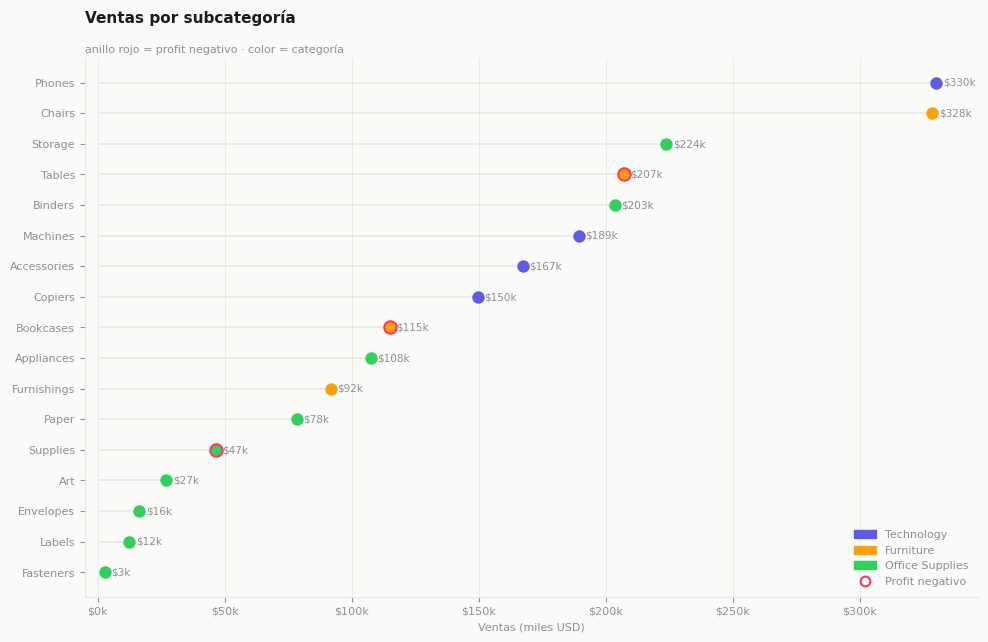

In [12]:
sub = (fs.groupby(["Category", "Sub-Category"])
         .agg(Sales=("Sales","sum"), Profit=("Profit","sum"))
         .reset_index()
         .sort_values("Sales"))

fig, ax = plt.subplots(figsize=(10, 6.5), facecolor=C["bg"])
cat_color = dict(zip(CATS, CCOLOR))

for _, row in sub.iterrows():
    col = cat_color[row["Category"]]
    profitable = row["Profit"] >= 0
    ax.hlines(row["Sub-Category"], 0, row["Sales"]/1e3,
              color=C["grid"], linewidth=1.2, zorder=1)
    ax.scatter(row["Sales"]/1e3, row["Sub-Category"],
               color=col, s=80, zorder=3,
               edgecolors="white" if profitable else C["accent"],
               linewidths=1.5 if not profitable else 0)
    ax.text(row["Sales"]/1e3 + 2.5, row["Sub-Category"],
            f'${row["Sales"]/1e3:.0f}k',
            va="center", fontsize=7.5, color=C["muted"])

ax.set_xlabel("Ventas (miles USD)", fontsize=8, color=C["muted"])
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"${x:.0f}k"))
ax.set_xlim(left=-5)
ax.grid(axis="y", linewidth=0)

legend_els = [mpatches.Patch(color=c, label=l)
              for l,c in zip(CATS, CCOLOR)]
legend_els.append(Line2D([0],[0], marker="o", color="w",
                         markerfacecolor=C["bg"],
                         markeredgecolor=C["accent"],
                         markeredgewidth=1.5, markersize=7,
                         label="Profit negativo"))
ax.legend(handles=legend_els, frameon=False, fontsize=8,
          labelcolor=C["muted"], loc="lower right")
title(ax, "Ventas por subcategoría")
subtitle(ax, "anillo rojo = profit negativo · color = categoría")
plt.tight_layout()
plt.show()


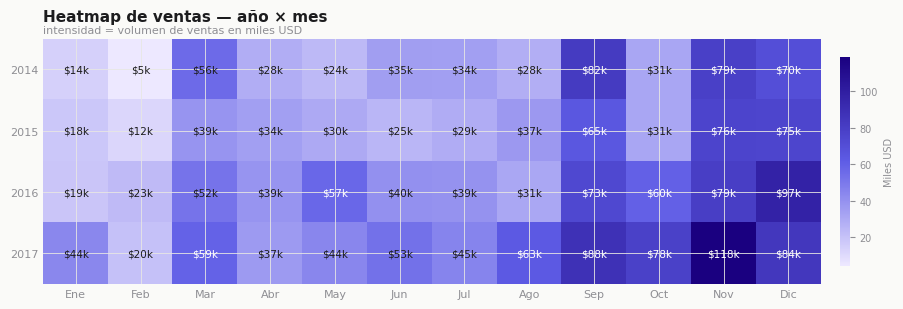

In [13]:
import matplotlib.colors as mcolors

pivot = (fs.groupby(["Year","Month"])["Sales"]
           .sum().unstack(fill_value=0) / 1e3)

fig, ax = plt.subplots(figsize=(10, 3.2), facecolor=C["bg"])
ax.set_facecolor(C["bg"])

vmin, vmax = pivot.values.min(), pivot.values.max()
cmap = mcolors.LinearSegmentedColormap.from_list(
    "retail", ["#EDE8FF", "#5E5CE6", "#1A0080"])

im = ax.imshow(pivot.values, aspect="auto", cmap=cmap,
               vmin=vmin, vmax=vmax)

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        brightness = (val - vmin) / (vmax - vmin)
        txt_color = "white" if brightness > 0.45 else C["ink"]
        ax.text(j, i, f"${val:.0f}k", ha="center", va="center",
                fontsize=7.5, color=txt_color, fontweight="500")

ax.set_xticks(range(12))
ax.set_xticklabels(["Ene","Feb","Mar","Abr","May","Jun",
                    "Jul","Ago","Sep","Oct","Nov","Dic"])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.ax.tick_params(labelsize=7, colors=C["muted"])
cbar.outline.set_visible(False)
cbar.set_label("Miles USD", fontsize=7, color=C["muted"])

title(ax, "Heatmap de ventas — año × mes")
subtitle(ax, "intensidad = volumen de ventas en miles USD")
plt.tight_layout()
plt.show()


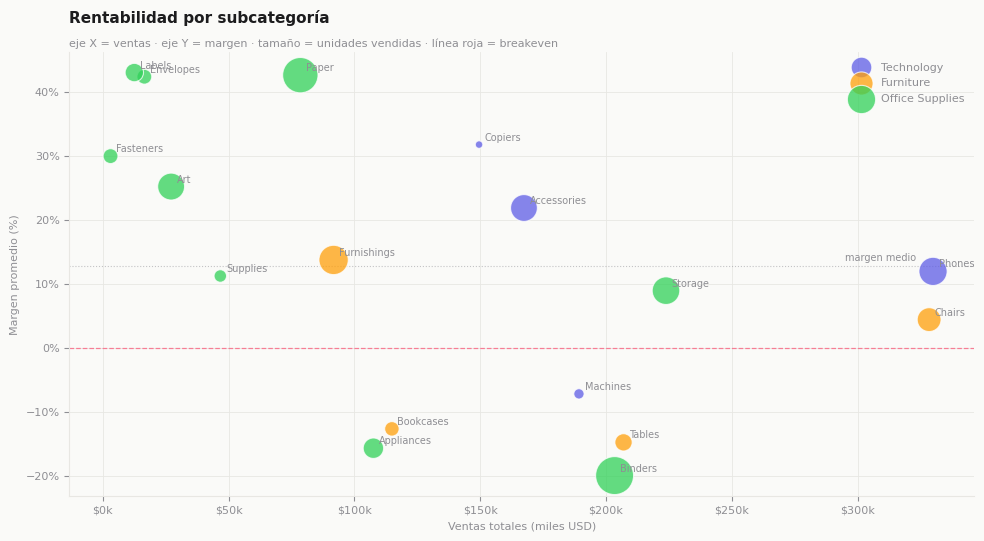

In [14]:
bubble = (fs.groupby(["Category","Sub-Category"])
            .agg(Sales=("Sales","sum"),
                 Profit=("Profit","sum"),
                 Margin=("Profit_Margin","mean"),
                 Qty=("Quantity","sum"))
            .reset_index())

fig, ax = plt.subplots(figsize=(10, 5.5), facecolor=C["bg"])

for cat, col in zip(CATS, CCOLOR):
    sub_b = bubble[bubble["Category"] == cat]
    sc = ax.scatter(sub_b["Sales"]/1e3, sub_b["Margin"]*100,
                    s=sub_b["Qty"]/8, color=col, alpha=0.75,
                    edgecolors="white", linewidths=0.8, label=cat, zorder=3)
    for _, row in sub_b.iterrows():
        ax.annotate(row["Sub-Category"],
                    xy=(row["Sales"]/1e3, row["Margin"]*100),
                    xytext=(4, 3), textcoords="offset points",
                    fontsize=7, color=C["muted"])

ax.axhline(0, color=C["accent"], linewidth=0.9, linestyle="--", alpha=0.6)
ax.axhline(bubble["Margin"].mean()*100, color=C["muted"],
           linewidth=0.8, linestyle=":", alpha=0.5)
ax.text(bubble["Sales"].max()/1e3*0.98,
        bubble["Margin"].mean()*100 + 0.8,
        "margen medio", ha="right", fontsize=7, color=C["muted"])

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"${x:.0f}k"))
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(frameon=False, fontsize=8, labelcolor=C["muted"])
ax.set_xlabel("Ventas totales (miles USD)", fontsize=8, color=C["muted"])
ax.set_ylabel("Margen promedio (%)", fontsize=8, color=C["muted"])
title(ax, "Rentabilidad por subcategoría")
subtitle(ax, "eje X = ventas · eje Y = margen · tamaño = unidades vendidas · línea roja = breakeven")
plt.tight_layout()
plt.show()


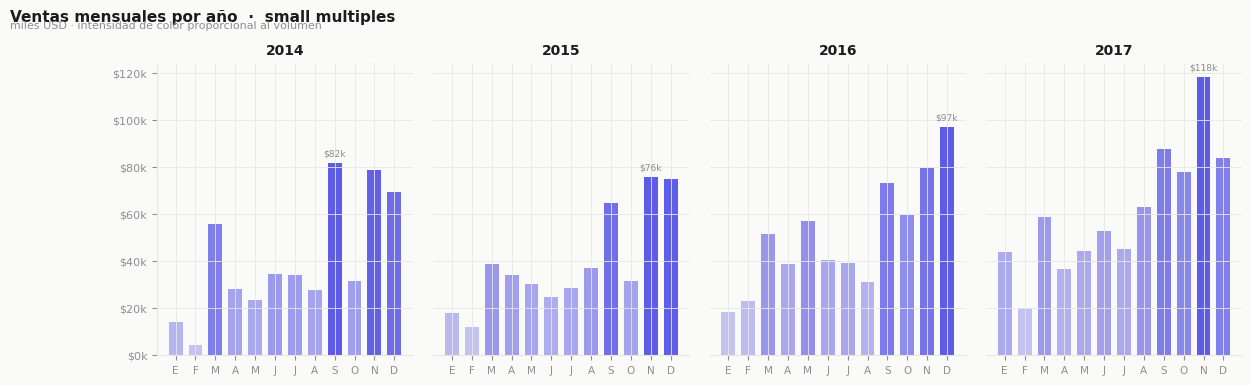

In [15]:
years = sorted(fs["Year"].unique())
months_lbl = ["E","F","M","A","M","J","J","A","S","O","N","D"]

fig, axes = plt.subplots(1, len(years), figsize=(14, 3.8),
                          facecolor=C["bg"], sharey=True,
                          gridspec_kw=dict(wspace=0.08))
fig.patch.set_facecolor(C["bg"])

for ax, yr in zip(axes, years):
    grp = (fs[fs["Year"]==yr]
           .groupby("Month")["Sales"].sum().reindex(range(1,13), fill_value=0))
    norm = (grp - grp.min()) / (grp.max() - grp.min() + 1e-9)

    colors_bar = [
        mcolors.to_rgba(C["tech"], alpha=0.35 + 0.65*v)
        for v in norm
    ]
    bars = ax.bar(range(1,13), grp/1e3, color=colors_bar,
                  width=0.7, edgecolor="none")
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(months_lbl, fontsize=7.5)
    ax.set_title(str(yr), fontsize=10, fontweight="600",
                 color=C["ink"], pad=6)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"${x:.0f}k"))
    if ax != axes[0]:
        ax.tick_params(left=False)
        ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color(C["grid"])
    ax.set_facecolor(C["bg"])
    # peak annotation
    peak_m = grp.idxmax()
    ax.annotate(f"${grp[peak_m]/1e3:.0f}k",
                xy=(peak_m, grp[peak_m]/1e3),
                xytext=(0, 5), textcoords="offset points",
                fontsize=6.5, ha="center", color=C["muted"])

fig.suptitle("Ventas mensuales por año  ·  small multiples",
             fontsize=11, fontweight="bold", color=C["ink"],
             x=0.02, ha="left", y=1.02)
fig.text(0.02, 0.97, "miles USD · intensidad de color proporcional al volumen",
         fontsize=8, color=C["muted"])
plt.show()


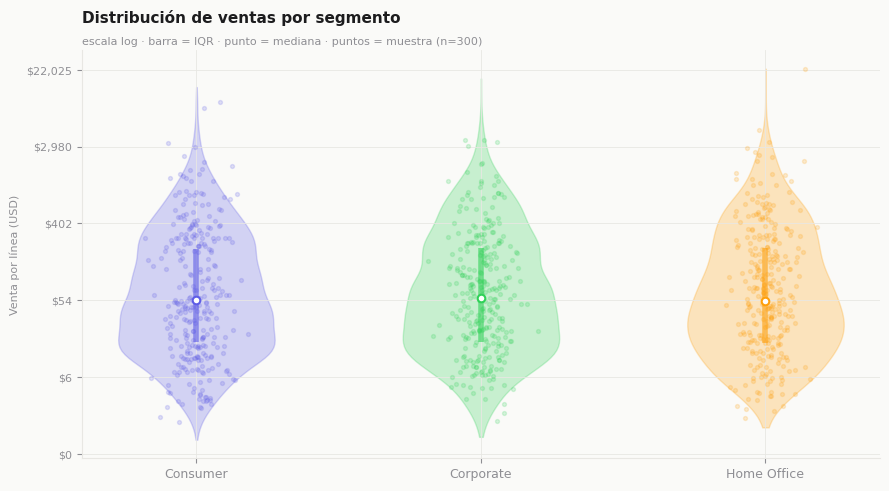

In [16]:
import matplotlib.patheffects as pe

segments = fs["Segment"].unique()
seg_colors = {"Consumer": C["tech"], "Corporate": C["off"],
              "Home Office": C["furn"]}

fig, ax = plt.subplots(figsize=(9, 5), facecolor=C["bg"])

data_by_seg = [np.log1p(fs[fs["Segment"]==s]["Sales"].values)
               for s in segments]

parts = ax.violinplot(data_by_seg, positions=range(len(segments)),
                      widths=0.55, showmedians=False,
                      showextrema=False)

for i, (pc, seg) in enumerate(zip(parts["bodies"], segments)):
    col = seg_colors[seg]
    pc.set_facecolor(col)
    pc.set_alpha(0.25)
    pc.set_edgecolor(col)
    pc.set_linewidth(1)

    q1, med, q3 = np.percentile(data_by_seg[i], [25, 50, 75])
    ax.vlines(i, q1, q3, color=col, linewidth=4, alpha=0.6, zorder=3)
    ax.scatter(i, med, color="white", s=30, zorder=5,
               edgecolors=col, linewidths=1.5)

    # strip (jitter)
    jitter = np.random.normal(i, 0.06, size=min(300, len(data_by_seg[i])))
    sample_idx = np.random.choice(len(data_by_seg[i]),
                                   min(300, len(data_by_seg[i])), replace=False)
    ax.scatter(jitter, np.array(data_by_seg[i])[sample_idx],
               color=col, alpha=0.18, s=8, zorder=2)

ax.set_xticks(range(len(segments)))
ax.set_xticklabels(segments, fontsize=9)
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x,_: f"${np.expm1(x):,.0f}"))
ax.set_ylabel("Venta por línea (USD)", fontsize=8, color=C["muted"])
title(ax, "Distribución de ventas por segmento")
subtitle(ax, "escala log · barra = IQR · punto = mediana · puntos = muestra (n=300)")
plt.tight_layout()
plt.show()


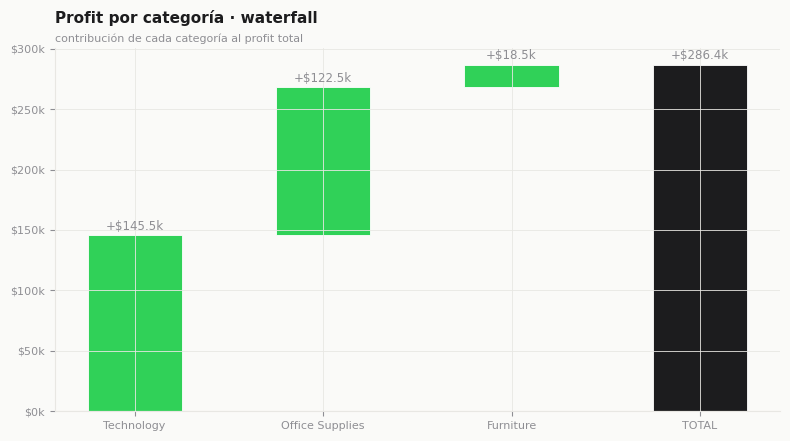

In [17]:
wp = (fs.groupby("Category")["Profit"]
        .sum().sort_values(ascending=False)
        .reset_index())
total = wp["Profit"].sum()
wp = pd.concat([wp,
                pd.DataFrame([{"Category":"TOTAL","Profit":total}])],
               ignore_index=True)

running = 0
bottoms, heights, colors_wf = [], [], []
for i, row in wp.iterrows():
    if row["Category"] == "TOTAL":
        bottoms.append(0); heights.append(row["Profit"])
        colors_wf.append(C["ink"])
    else:
        bottoms.append(running); heights.append(row["Profit"])
        colors_wf.append(C["off"] if row["Profit"] >= 0 else C["accent"])
        running += row["Profit"]

fig, ax = plt.subplots(figsize=(8, 4.5), facecolor=C["bg"])
bars = ax.bar(wp["Category"], heights, bottom=bottoms,
              color=colors_wf, width=0.5,
              edgecolor="white", linewidth=0.6)

for bar, (_, row) in zip(bars, wp.iterrows()):
    ypos = bar.get_y() + bar.get_height()
    sign = "+" if row["Profit"] > 0 else ""
    ax.text(bar.get_x() + bar.get_width()/2,
            ypos + total*0.008,
            f'{sign}${row["Profit"]/1e3:.1f}k',
            ha="center", va="bottom", fontsize=8.5, color=C["muted"])

ax.axhline(0, color=C["grid"], linewidth=0.8)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"${x/1e3:.0f}k"))
ax.set_facecolor(C["bg"])
title(ax, "Profit por categoría · waterfall")
subtitle(ax, "contribución de cada categoría al profit total")
plt.tight_layout()
plt.show()
